In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [2]:
np.random.seed(42)
rows = 200

data = {
    "Engine_Size_L": np.random.uniform(0.8, 4.5, rows),
    "Cylinders": np.random.choice([3, 4, 6, 8], rows),
    "Vehicle_Weight_kg": np.random.randint(800, 2500, rows),
    "Horsepower": np.random.randint(60, 400, rows),
    "City_Driving_pct": np.random.randint(20, 80, rows),
    "Highway_Driving_pct": np.random.randint(20, 80, rows)
}

df = pd.DataFrame(data)


In [3]:
df["Fuel_Consumption_kmpl"] = (
    25
    - 2.5 * df["Engine_Size_L"]
    - 0.02 * df["Vehicle_Weight_kg"]
    - 0.01 * df["Horsepower"]
    + 0.05 * df["Highway_Driving_pct"]
    + np.random.normal(0, 1.2, rows)
)


In [4]:
print(df.head())
print(df.shape)   # (200, 7)


   Engine_Size_L  Cylinders  Vehicle_Weight_kg  Horsepower  City_Driving_pct  \
0       2.185798          8               1676         112                76   
1       4.317643          8               1791         210                57   
2       3.508378          6               1683         203                52   
3       3.015036          3               2173         116                43   
4       1.377269          8                846          98                34   

   Highway_Driving_pct  Fuel_Consumption_kmpl  
0                   43             -11.536127  
1                   50             -20.784301  
2                   25             -18.345311  
3                   21             -25.715883  
4                   39               5.118494  
(200, 7)


In [6]:
X = df.drop("Fuel_Consumption_kmpl", axis=1)
y = df["Fuel_Consumption_kmpl"]


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [8]:
model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Actual_Fuel_Consumption": y_test.values,
    "Predicted_Fuel_Consumption": y_pred
})

print(results.head())


   Actual_Fuel_Consumption  Predicted_Fuel_Consumption
0               -15.433706                  -15.882430
1                -7.476655                   -6.492621
2               -11.441810                  -10.914665
3               -27.154294                  -26.855477
4               -13.122743                  -12.604332


In [10]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))


MAE: 1.157656042114581
MSE: 2.1265783147861432
R² Score: 0.9737373375717024


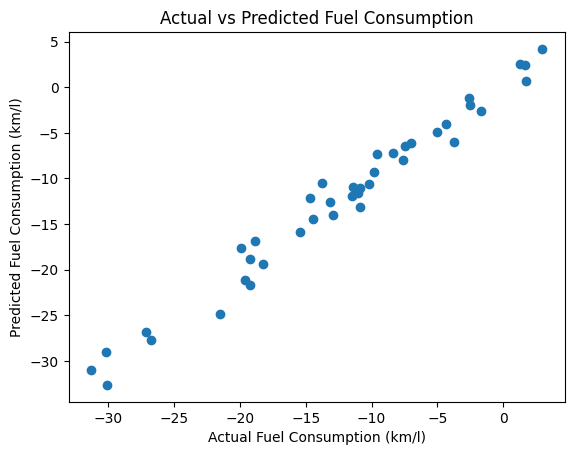

In [11]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Fuel Consumption (km/l)")
plt.ylabel("Predicted Fuel Consumption (km/l)")
plt.title("Actual vs Predicted Fuel Consumption")
plt.show()
